# Assignment 2: Credit, Derivative, Liquidity & Operational Risk

Same three companies as before (AAPL, PFE, XOM) and the equity volatilities I estimated for them. Data is a dated snapshot and every simulation is seeded, so this reproduces.

In [1]:
import os, warnings, itertools
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, skew, kurtosis
from scipy.optimize import fsolve
from IPython.display import display
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12})
BLUE, RED, GREEN, GOLD = '#2C7BB6', '#D7191C', '#1A9641', '#F39C12'

STOCKS = ['AAPL', 'PFE', 'XOM']
RF, LGD, RECOV = 0.04, 0.45, 0.55

px   = pd.read_csv('../A1/my_portfolio.csv', index_col=0, parse_dates=True)
rets = np.log(px / px.shift(1)).dropna()
SIGMA_E = (rets[STOCKS].std() * np.sqrt(252)).to_dict()

W        = np.array([1/3, 1/3, 1/3])
r_port   = px[STOCKS].pct_change().dropna() @ W
var_base = -(r_port.mean() + stats.norm.ppf(0.01) * r_port.std())

E      = {'AAPL': 4.660445e12, 'PFE': 1.395224e11, 'XOM': 5.989863e11}
D      = {'AAPL': 8.4711e10,   'PFE': 6.4731e10,   'XOM': 4.7661e10}
PRICE  = {'AAPL': 317.31, 'PFE': 24.48, 'XOM': 144.51}
RATING = {'AAPL': 'AA+',  'PFE': 'A',   'XOM': 'AA-'}
SPREAD = {'AAPL': 0.0035, 'PFE': 0.0070, 'XOM': 0.0045}
RATING_PD = {'AA+': 0.0002, 'AA-': 0.0002, 'A': 0.0005}

print('Equity vol:', {k: round(v, 3) for k, v in SIGMA_E.items()})
print(f'Portfolio 1-day 99% VaR: {var_base*100:.2f}%')

Equity vol: {'AAPL': 0.262, 'PFE': 0.242, 'XOM': 0.233}
Portfolio 1-day 99% VaR: 2.32%


## 1 · Merton structural model & default probability

Equity is a call option on the firm's assets, struck at the debt face. Assets are not observable, so I solve the two Merton equations for asset value and volatility from E, my equity volatility and D, giving the distance-to-default and PD = N(-DD). E and D are each firm's market cap and total debt from Yahoo Finance, the same source as my price snapshot, pinned here as fixed inputs so every rerun reproduces. They are pulled shortly after the 30 June close that ends my return series, which is why AAPL's $4.66tn cap sits on a $317.31 spot rather than the $289.36 my snapshot ends on. Merton wants today's equity value while the volatility comes from three years of history, so the offset is deliberate. The ratings are S&P's whole-letter grades and the spreads are indicative investment-grade levels for those grades, not quoted CDS.

Three approximations bend the PD. The risk-free rate stands in for the asset drift, so the PD is risk-neutral and sits above the real-world frequency. Total debt as the barrier is conservative too. Cutting the other way, the debt is one zero-coupon bond maturing in a year, so default can only strike on that date.

,Rating,Spread (bp),Leverage %,Asset vol,DD (Merton),PD Merton,PD rating,PD CDS,DD implied by CDS
Firm,,,,,,,,,
AAPL,AA+,35.0,1.8,0.258,15.66,1.52e-55,0.020%,0.778%,2.42
PFE,A,70.0,31.7,0.167,6.96,1.74e-12,0.050%,1.556%,2.16
XOM,AA-,45.0,7.4,0.216,12.13,3.88e-34,0.020%,1.000%,2.33


The same firm, three PD measures (1-year):
  AAPL  Merton 1.52e-55   rating 0.020%   CDS 0.778%   |  DD: model 15.7 sigma vs CDS-implied 2.4 sigma
  PFE   Merton 1.74e-12   rating 0.050%   CDS 1.556%   |  DD: model 7.0 sigma vs CDS-implied 2.2 sigma
  XOM   Merton 3.88e-34   rating 0.020%   CDS 1.000%   |  DD: model 12.1 sigma vs CDS-implied 2.3 sigma


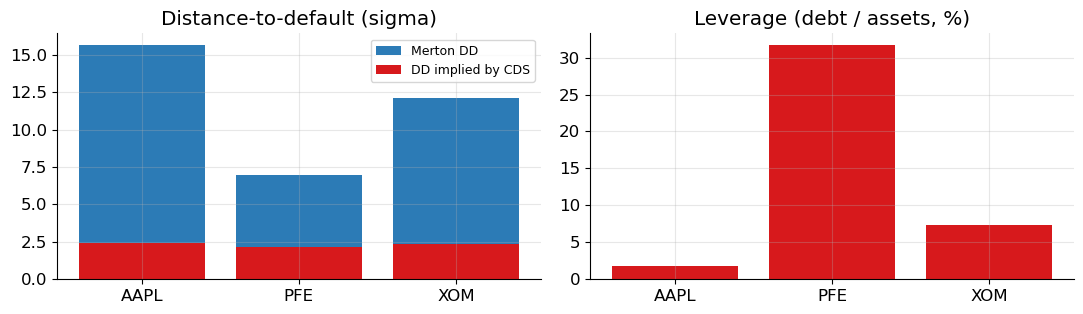

In [2]:
def merton_calibrate(E_obs, sigma_E, D_face, r=RF, T=1.0):
    def eqs(x):
        V, sV = x
        d1 = (np.log(V/D_face) + (r + 0.5*sV**2)*T) / (sV*np.sqrt(T))
        d2 = d1 - sV*np.sqrt(T)
        return [V*norm.cdf(d1) - D_face*np.exp(-r*T)*norm.cdf(d2) - E_obs,
                norm.cdf(d1)*sV*V - sigma_E*E_obs]
    V, sV = fsolve(eqs, [E_obs + D_face, sigma_E*E_obs/(E_obs+D_face)])
    dd = (np.log(V/D_face) + (r - 0.5*sV**2)*T) / (sV*np.sqrt(T))
    return V, sV, dd, norm.cdf(-dd)

rows = []
for s in STOCKS:
    V, sV, dd, pd_ = merton_calibrate(E[s], SIGMA_E[s], D[s])
    cds_pd, rat_pd = SPREAD[s]/(1-RECOV), RATING_PD[RATING[s]]
    rows.append({'Firm': s, 'Rating': RATING[s], 'Spread (bp)': SPREAD[s]*1e4,
                 'Leverage %': D[s]/(E[s]+D[s])*100,
                 'Asset vol': sV, 'DD (Merton)': dd, 'PD Merton': pd_,
                 'PD rating': rat_pd, 'PD CDS': cds_pd,
                 'DD implied by CDS': -norm.ppf(cds_pd)})
merton_df = pd.DataFrame(rows).set_index('Firm')

show = merton_df.round({'Spread (bp)': 0, 'Leverage %': 1, 'Asset vol': 3,
                        'DD (Merton)': 2, 'DD implied by CDS': 2})
show['PD Merton'] = merton_df['PD Merton'].map('{:.2e}'.format)
show['PD rating'] = merton_df['PD rating'].map('{:.3%}'.format)
show['PD CDS']    = merton_df['PD CDS'].map('{:.3%}'.format)
display(show)

print('The same firm, three PD measures (1-year):')
for s in STOCKS:
    r_ = merton_df.loc[s]
    print(f"  {s:5s} Merton {r_['PD Merton']:.2e}   rating {r_['PD rating']:.3%}   "
          f"CDS {r_['PD CDS']:.3%}   |  DD: model {r_['DD (Merton)']:.1f} sigma vs "
          f"CDS-implied {r_['DD implied by CDS']:.1f} sigma")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].bar(STOCKS, [merton_df.loc[s, 'DD (Merton)'] for s in STOCKS], color=BLUE, label='Merton DD')
ax[0].bar(STOCKS, [merton_df.loc[s, 'DD implied by CDS'] for s in STOCKS], color=RED,
          label='DD implied by CDS')
ax[0].set_title('Distance-to-default (sigma)'); ax[0].legend(fontsize=9)
ax[1].bar(STOCKS, [D[s]/(E[s]+D[s])*100 for s in STOCKS], color=RED)
ax[1].set_title('Leverage (debt / assets, %)')
plt.tight_layout(); plt.show()

**Interpretation:** The structural PDs are microscopically small for all three names, which is what I expect for healthy large caps and is a real finding rather than a bug. PFE is the highest at about 1.7e-12 because it carries the most leverage, with debt near 32% of assets, while AAPL sits 15.7 sigma out at around 1e-55. The ordering matches the agency ratings, so the model ranks the firms sensibly.

The interesting part is lining all three PD measures up for one firm. For AAPL the market charges a 35bp spread, implying a 0.78% one-year PD, the rating tables say an AA+ name defaults about 0.02% of the time, and Merton says 1e-55. Those are not small disagreements, they are different universes. The market prices AAPL as if it sits 2.4 sigma from default, Merton says 15.7, so the model is off by 13 sigma. The CDS number is too high because dividing the whole spread by one minus recovery blames all of it on default, when much of a spread is really a risk premium and compensation for illiquidity.

There is an apples-to-oranges problem underneath the gap. My Merton PD and the CDS PD are both risk-neutral, priced as if nobody demands a premium for default risk, while the rating table counts how often AA+ names actually defaulted. Risk-neutral numbers should sit above real-world ones, and the CDS PD duly does at 0.78% against the rating's 0.02%. Merton breaks the pattern, landing below the real-world rate by fifty-odd orders of magnitude despite the same conservative convention. The thin Normal tail is not just a caveat, it is strong enough to swamp a bias that should have pushed the other way. Real firms gap into default and this model only lets them drift. Section 2 runs on the CDS PDs because they are conservative and, unlike 1e-55, not zero.

## 2 · Loan book & Monte-Carlo portfolio loss

I run on the CDS-implied PDs from section 1. The structural ones are too small to lose anything worth simulating.

     EAD weight PD (CDS-implied)
AAPL      43.0%           0.778%
PFE       32.8%           1.556%
XOM       24.2%           1.000%
Expected loss: 0.489% of book  |  EAD-weighted avg PD: 1.09%

3-name concentrated book. Credit VaR nets off expected loss, and
economic capital is the 99.9% Credit VaR:
    rho    VaR99  VaR99.9   CVaR99  CVaR99.9    ES99   ES99.9
   0.05   14.78%   19.34%   14.29%    18.85%  16.62%   20.02%
   0.15   14.78%   19.34%   14.29%    18.85%  16.82%   20.48%
   0.30   14.78%   30.22%   14.29%    29.73%  17.35%   33.39%

Every possible outcome of a 3-name book (loss atoms and their probability %):
  defaults            loss    rho=0.05    rho=0.15     rho=0.3
  ------------------------------------------------------------


  AAPL + PFE + XOM  45.00%      0.000%      0.002%      0.008%
  AAPL + PFE        34.12%      0.017%      0.029%      0.056%
  AAPL + XOM        30.22%      0.011%      0.019%      0.039%
  PFE + XOM         25.66%      0.019%      0.036%      0.073%


  AAPL              19.34%      0.747%      0.722%      0.670%
  PFE               14.78%      1.517%      1.487%      1.411%
  XOM               10.88%      0.964%      0.944%      0.880%
  none               0.00%     96.726%     96.760%     96.862%

Granular homogeneous pool (N=1000 at avg PD) vs Vasicek analytic:
   rho   sim VaR99.9  Vasicek99.9


  0.05         2.39%        2.25%


  0.15         5.45%        5.26%


  0.30        10.89%       10.61%


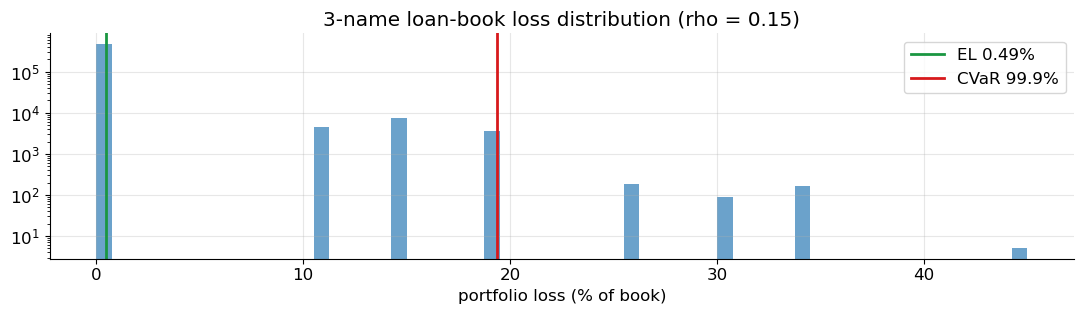

In [3]:
book = pd.DataFrame(index=STOCKS)
book['EAD weight']       = np.array([D[s] for s in STOCKS]); book['EAD weight'] /= book['EAD weight'].sum()
book['PD (CDS-implied)'] = [SPREAD[s]/(1-RECOV) for s in STOCKS]
EAD, PD = book['EAD weight'].values, book['PD (CDS-implied)'].values
EL, pdbar = (EAD*LGD*PD).sum(), (EAD*PD).sum()

disp = book.copy()
disp['EAD weight']       = disp['EAD weight'].map('{:.1%}'.format)
disp['PD (CDS-implied)'] = disp['PD (CDS-implied)'].map('{:.3%}'.format)
print(disp.to_string())
print(f'Expected loss: {EL*100:.3f}% of book  |  EAD-weighted avg PD: {pdbar*100:.2f}%')

def simulate_portfolio_loss(PD, EAD, LGD, rho, n=500_000, seed=42, matrix=False):
    g = np.random.default_rng(seed)
    A = np.sqrt(rho)*g.standard_normal((n, 1)) + np.sqrt(1-rho)*g.standard_normal((n, len(PD)))
    Dmat = A < norm.ppf(PD)
    return Dmat if matrix else (Dmat * EAD * LGD).sum(axis=1)

def vasicek_var(conf, PD, LGD, rho):
    num = norm.ppf(PD) + np.sqrt(rho) * norm.ppf(conf)
    cond_pd = norm.cdf(num / np.sqrt(1 - rho))
    return cond_pd * LGD

RHOS = [0.05, 0.15, 0.30]
print('\n3-name concentrated book. Credit VaR nets off expected loss, and')
print('economic capital is the 99.9% Credit VaR:')
print(f"  {'rho':>5}{'VaR99':>9}{'VaR99.9':>9}{'CVaR99':>9}{'CVaR99.9':>10}{'ES99':>8}{'ES99.9':>9}")
loss_show = None
for rho in RHOS:
    L = simulate_portfolio_loss(PD, EAD, LGD, rho)
    v99, v999 = np.percentile(L, 99), np.percentile(L, 99.9)
    print(f'  {rho:>5.2f}{v99*100:8.2f}%{v999*100:8.2f}%{(v99-EL)*100:8.2f}%{(v999-EL)*100:9.2f}%'
          f'{L[L>=v99].mean()*100:7.2f}%{L[L>=v999].mean()*100:8.2f}%')
    if rho == 0.15: loss_show = L

print('\nEvery possible outcome of a 3-name book (loss atoms and their probability %):')
hdr = f"  {'defaults':<16}{'loss':>8}" + ''.join(f'{"rho="+str(r):>12}' for r in RHOS)
print(hdr); print('  ' + '-'*(len(hdr)-2))
Dmats = {rho: simulate_portfolio_loss(PD, EAD, LGD, rho, n=2_000_000, seed=1, matrix=True)
         for rho in RHOS}
atoms = []
for combo in itertools.product([0, 1], repeat=3):
    nm = ' + '.join(s for s, c in zip(STOCKS, combo) if c) or 'none'
    atoms.append((nm, np.array(combo), (np.array(combo)*EAD*LGD).sum()))
for nm, combo, loss in sorted(atoms, key=lambda a: -a[2]):
    ps = [np.all(Dmats[rho] == combo, axis=1).mean()*100 for rho in RHOS]
    print(f'  {nm:<16}{loss*100:7.2f}%' + ''.join(f'{p:>11.3f}%' for p in ps))

print('\nGranular homogeneous pool (N=1000 at avg PD) vs Vasicek analytic:')
print(f"  {'rho':>4} {'sim VaR99.9':>13} {'Vasicek99.9':>12}")
PDp, EADp = np.full(1000, pdbar), np.full(1000, 1/1000)
for rho in RHOS:
    L = simulate_portfolio_loss(PDp, EADp, LGD, rho, n=200_000)
    print(f"  {rho:>4.2f} {np.percentile(L,99.9)*100:12.2f}% {vasicek_var(0.999,pdbar,LGD,rho)*100:11.2f}%")

fig, ax = plt.subplots(figsize=(11, 3.3))
ax.hist(loss_show*100, bins=60, color=BLUE, alpha=.7)
ax.axvline(EL*100, color=GREEN, lw=2, label=f'EL {EL*100:.2f}%')
ax.axvline(np.percentile(loss_show,99.9)*100, color=RED, lw=2, label='CVaR 99.9%')
ax.set_yscale('log'); ax.set_xlabel('portfolio loss (% of book)')
ax.set_title('3-name loan-book loss distribution (rho = 0.15)'); ax.legend()
plt.tight_layout(); plt.show()

**Interpretation:** Expected loss is tiny at 0.489% of the book, but the tail is brutal, and the reason is concentration. One PFE default alone costs 14.78%, so the 99% VaR sits exactly there, a 14.29% Credit VaR once I net off the expected loss I am provisioned for. Economic capital, the 99.9% Credit VaR, runs from 18.85% to 29.73% depending on correlation, and ES makes the point more honestly: at rho = 0.30 the 99.9% ES is 33.39% against a 30.22% VaR, so the average disaster is worse than the one I hold capital against. A granular pool tells the opposite story, with a thousand borrowers at the same average PD giving a 99.9% VaR of 2.39%, 5.45% and 10.89%, tracking Vasicek (2.25%, 5.26%, 10.61%) almost exactly. Basel's formula assumes that pool, so it charges only for systematic risk, and my three names have nothing to diversify with.

What I did not expect is the 99% VaR frozen at 14.78% for every correlation, so I printed all eight outcomes to see why. Three names cannot make a smooth loss distribution, only eight atoms, and the 99% quantile has to land on one. Losing PFE alone carries about 1.5% probability and everything worse adds to roughly 2.3%, so the 1% tail sits inside that atom whatever correlation does. Correlation is not doing nothing, it is doing it where the 99% number cannot see: raising rho from 0.05 to 0.30 barely moves the single-default atoms (PFE drifts 1.517% to 1.411%) but more than triples every joint one, so AAPL and PFE together goes from 0.017% to 0.056%. Once the combined two-name mass clears 0.1%, the 99.9% quantile stops landing on AAPL alone at 19.34% and jumps to the AAPL and XOM atom at 30.22%.

So a 99% number on three names is close to meaningless, quantising to an atom and sitting still while the real risk moves underneath. And this is the honest copula critique: the Gaussian factor raises joint defaults from very small to still small, whereas in a crisis correlations run toward 1 and those atoms become the main event.

## 3 · Derivatives: pricing, Greeks & VaR

I shock the spot only and hold time fixed, so the VaR isolates what delta and gamma describe.

3-month ATM AAPL call | S0 = K = $317.31, sigma = 26.2%, r = 4%
Black-Scholes: $18.1170

CRR binomial convergence to Black-Scholes:
  N=    5   CRR $ 18.9468   error  +0.8298
  N=   10   CRR $ 17.7093   error  -0.4077
  N=   25   CRR $ 18.2807   error  +0.1638
  N=   50   CRR $ 18.0345   error  -0.0825
  N=  100   CRR $ 18.0757   error  -0.0413
  N=  250   CRR $ 18.1004   error  -0.0165
  N=  500   CRR $ 18.1087   error  -0.0083
  N= 2000   CRR $ 18.1149   error  -0.0021


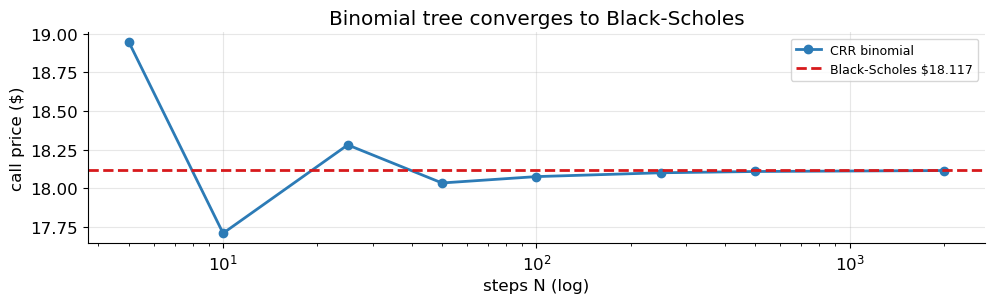

In [4]:
def bs_d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_d2(S, K, T, r, sigma):
    return bs_d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_call(S, K, T, r, sigma):
    d1, d2 = bs_d1(S, K, T, r, sigma), bs_d2(S, K, T, r, sigma)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_delta(S, K, T, r, sigma, option='call'):
    d1 = bs_d1(S, K, T, r, sigma)
    if option == 'call':
        return norm.cdf(d1)
    return norm.cdf(d1) - 1

def bs_gamma(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T) / 100

def bs_theta(S, K, T, r, sigma, option='call'):
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = bs_d2(S, K, T, r, sigma)
    term1 = -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
    if option == 'call':
        return (term1 - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    return (term1 + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365

def crr_price(S, K, T, r, sigma, N, option='call', style='european'):
    dt   = T / N
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1.0 / u
    p    = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    j       = np.arange(N + 1)
    ST      = S * u**j * d**(N - j)

    if option == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)

    for i in range(N - 1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])
        if style == 'american':
            S_i = S * u**np.arange(i + 1) * d**(i - np.arange(i + 1))
            if option == 'call':
                V = np.maximum(V, S_i - K)
            else:
                V = np.maximum(V, K - S_i)
    return V[0]

S0, K, T_OPT, SIG = PRICE['AAPL'], PRICE['AAPL'], 0.25, SIGMA_E['AAPL']
call_bs = bs_call(S0, K, T_OPT, RF, SIG)
print(f'3-month ATM AAPL call | S0 = K = ${S0:.2f}, sigma = {SIG:.1%}, r = {RF:.0%}')
print(f'Black-Scholes: ${call_bs:.4f}\n')
print('CRR binomial convergence to Black-Scholes:')
Ns = [5, 10, 25, 50, 100, 250, 500, 2000]
crr = [crr_price(S0, K, T_OPT, RF, SIG, N) for N in Ns]
for N, c in zip(Ns, crr):
    print(f'  N={N:>5}   CRR ${c:8.4f}   error {c-call_bs:+8.4f}')

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(Ns, crr, 'o-', color=BLUE, lw=2, label='CRR binomial')
ax.axhline(call_bs, color=RED, ls='--', lw=2, label=f'Black-Scholes ${call_bs:.3f}')
ax.set_xscale('log'); ax.set_xlabel('steps N (log)'); ax.set_ylabel('call price ($)')
ax.set_title('Binomial tree converges to Black-Scholes'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

Greeks: delta 0.5564   gamma 0.00950   vega $0.6266 per +1% vol   theta $-0.1073 per day

 horizon  position   full reval   delta-gamma   delta-only   delta-only error
   1-day    long  $      6.06  $       6.08  $      6.78             11.9%
   1-day   short  $      7.48  $       7.50  $      6.79             -9.2%
  10-day    long  $     14.29  $      14.37  $     21.39             49.6%
  10-day   short  $     27.50  $      28.42  $     21.40            -22.2%


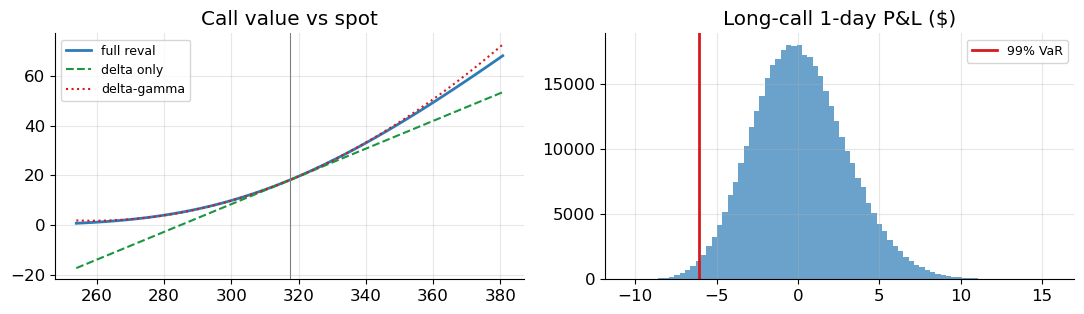

In [5]:
delta = bs_delta(S0, K, T_OPT, RF, SIG)
gamma = bs_gamma(S0, K, T_OPT, RF, SIG)
vega  = bs_vega (S0, K, T_OPT, RF, SIG)
theta = bs_theta(S0, K, T_OPT, RF, SIG)
print(f'Greeks: delta {delta:.4f}   gamma {gamma:.5f}   vega ${vega:.4f} per +1% vol   '
      f'theta ${theta:.4f} per day')

g = np.random.default_rng(7)
var99 = lambda x: -np.percentile(x, 1)
print(f"\n{'horizon':>8}  {'position':>6}  {'full reval':>11}  {'delta-gamma':>12}  "
      f"{'delta-only':>11}  {'delta-only error':>17}")
for H, lab in [(1, '1-day'), (10, '10-day')]:
    dS = S0 * g.normal(0, SIG*np.sqrt(H/252), 400_000)
    pnl_full = bs_call(S0+dS, K, T_OPT, RF, SIG) - call_bs
    pnl_dg   = delta*dS + 0.5*gamma*dS**2
    pnl_do   = delta*dS
    for sign, nm in [(1, 'long'), (-1, 'short')]:
        f, dg, do = var99(sign*pnl_full), var99(sign*pnl_dg), var99(sign*pnl_do)
        print(f'{lab:>8}  {nm:>6}  ${f:>10.2f}  ${dg:>11.2f}  ${do:>10.2f}  {(do-f)/f:>16.1%}')
    if H == 1: pnl_1d = pnl_full

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
Sg = np.linspace(S0*.8, S0*1.2, 120)
ax[0].plot(Sg, bs_call(Sg, K, T_OPT, RF, SIG), color=BLUE, lw=2, label='full reval')
ax[0].plot(Sg, call_bs + delta*(Sg-S0), color=GREEN, ls='--', label='delta only')
ax[0].plot(Sg, call_bs + delta*(Sg-S0) + 0.5*gamma*(Sg-S0)**2, color=RED, ls=':', label='delta-gamma')
ax[0].axvline(S0, color='gray', lw=.8); ax[0].set_title('Call value vs spot'); ax[0].legend(fontsize=9)
ax[1].hist(pnl_1d, bins=80, color=BLUE, alpha=.7)
ax[1].axvline(-var99(pnl_1d), color=RED, lw=2, label='99% VaR')
ax[1].set_title('Long-call 1-day P&L ($)'); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation:** The tree converges onto Black-Scholes as it should, from $18.95 at 5 steps to $18.1149 at 2000 against the closed form's $18.1170, the error shrinking roughly like 1/N and alternating sign while the tree is coarse, then settling just below the closed form from 50 steps on. Agreeing to a fifth of a cent is my check that both are right. The option has delta 0.556, gamma 0.0095, vega $0.63 per point of vol and theta -$0.11 a day.

Gamma is the whole story for VaR. Long the call, delta-only reports a 1-day 99% VaR of $6.78 against a true $6.06, overstating by 12%, because positive gamma means the call loses less than the straight-line delta predicts as the spot falls. Short the call it flips: the true VaR is $7.48 and delta-only still says $6.79, understating by 9%. Delta-gamma catches both, at $6.08 and $7.50. The asymmetry is what matters, because the same wrong model is conservative for the buyer and dangerously optimistic for the seller, and it is the seller who has the unlimited downside.

A 10-day horizon degrades both legs, since the approximation expands around today's spot and decays as shocks grow: delta-only overstates the long by 50% and understates the short by 22%, and even delta-gamma drifts ($28.42 against $27.50). The long error grows faster, but the short error is the one that costs money, because being 22% short of capital is a solvency problem in a way that being 50% over is not. And gamma is not a gift: theta is -$0.11 a day, so the curvature that flatters my long VaR is rented, and I pay for it every day the spot sits still.

## 4 · Liquidity-adjusted VaR

A liquidity cost can come off a quoted spread or off my own price and volume data, so I build it both ways and compare.

     Amihud (x1e9) Avg $vol (bn) CS spread (bp) CS median (bp) CS days floored at 0 Quoted half-spread (bp)
AAPL        0.0009         11.95           43.2           10.3                  47%                     0.5
PFE         0.0110          1.04           46.7           17.7                  45%                     3.0
XOM         0.0058          1.96           42.0            0.0                  51%                     1.5

Sanity check: a real AAPL quoted spread is well under 1bp, so the CS mean of 43bp is far too wide and CS does not rank the three names.
I keep CS as a diagnostic and charge liquidity off Amihud instead.

On a $1bn book:
  Base VaR:                               2.32%
  Liquidity-adjusted VaR (my own Amihud): 2.52%   (cost 0.196%)
  Liquidity-adjusted VaR (quoted spread): 2.34%   (cost 0.017%)

Amihud is mean |return| per dollar of volume, so it scales with the position
while a quoted spread does not:
       book  Amihud cost    LVaR   quoted-spread LVaR
  $    

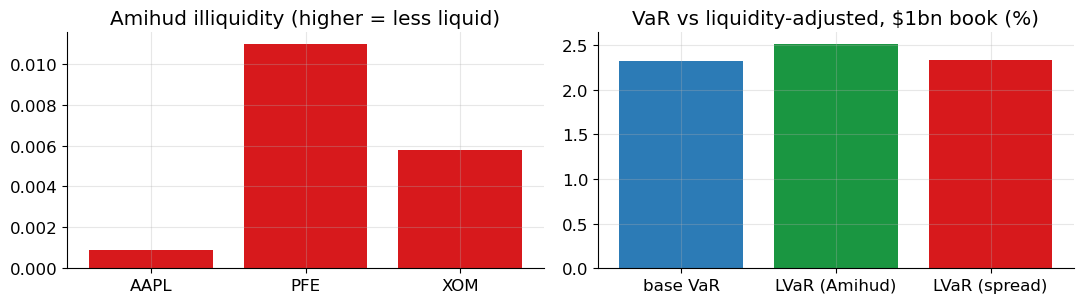

In [6]:
oh = pd.read_csv('a2_ohlcv.csv', index_col=0, parse_dates=True)
close  = oh[[f'close_{s}'  for s in STOCKS]]; close.columns  = STOCKS
volume = oh[[f'volume_{s}' for s in STOCKS]]; volume.columns = STOCKS
high   = oh[[f'high_{s}'   for s in STOCKS]]; high.columns   = STOCKS
low    = oh[[f'low_{s}'    for s in STOCKS]]; low.columns    = STOCKS
ret    = np.log(close/close.shift(1))

dollar_vol = (close * volume).replace(0, np.nan)
amihud = (ret.abs() / dollar_vol).mean() * 1e9
adv    = dollar_vol.mean()

def corwin_schultz_spread(high_s, low_s):
    h, l = high_s.values.astype(float), low_s.values.astype(float)
    h2, l2 = np.maximum(h[:-1], h[1:]), np.minimum(l[:-1], l[1:])
    beta  = (np.log(h[:-1]/l[:-1]))**2 + (np.log(h[1:]/l[1:]))**2
    gamma_ = (np.log(h2/l2))**2
    denom = 3 - 2*np.sqrt(2)
    alpha = (np.sqrt(2*beta) - np.sqrt(beta))/denom - np.sqrt(gamma_/denom)
    spread = 2*(np.exp(alpha) - 1) / (1 + np.exp(alpha))
    return pd.Series(np.where(alpha < 0, 0.0, spread), index=high_s.index[1:]), alpha

cs_df, cs_alpha = {}, {}
for s in STOCKS:
    cs_df[s], cs_alpha[s] = corwin_schultz_spread(high[s], low[s])
cs_df = pd.DataFrame(cs_df)

HALF_SPREAD = {'AAPL': 0.0001/2, 'PFE': 0.0006/2, 'XOM': 0.0003/2}

liq = pd.DataFrame({'Amihud (x1e9)': [f'{amihud[s]:.4f}' for s in STOCKS],
                    'Avg $vol (bn)': [f'{adv[s]/1e9:.2f}' for s in STOCKS],
                    'CS spread (bp)': [f'{cs_df[s].mean()*1e4:.1f}' for s in STOCKS],
                    'CS median (bp)': [f'{cs_df[s].median()*1e4:.1f}' for s in STOCKS],
                    'CS days floored at 0': [f'{(cs_alpha[s] < 0).mean():.0%}' for s in STOCKS],
                    'Quoted half-spread (bp)': [f'{HALF_SPREAD[s]*1e4:.1f}' for s in STOCKS]},
                   index=STOCKS)
print(liq.to_string())
print('\nSanity check: a real AAPL quoted spread is well under 1bp, so the CS mean of '
      f"{cs_df['AAPL'].mean()*1e4:.0f}bp is far too wide and CS does not rank the three names.")
print('I keep CS as a diagnostic and charge liquidity off Amihud instead.')

illiq_raw = (ret.abs() / dollar_vol).mean()

def amihud_liq_cost(book_value):
    return book_value * sum(W[i]**2 * illiq_raw[s] for i, s in enumerate(STOCKS))

BOOK        = 1_000_000_000
spread_cost = sum(W[i]*HALF_SPREAD[s] for i, s in enumerate(STOCKS))
amihud_cost = amihud_liq_cost(BOOK)
LVAR_SPREAD = var_base + spread_cost
LVAR        = var_base + amihud_cost

print(f'\nOn a ${BOOK/1e9:.0f}bn book:')
print(f'  Base VaR:                               {var_base*100:.2f}%')
print(f'  Liquidity-adjusted VaR (my own Amihud): {LVAR*100:.2f}%   (cost {amihud_cost*100:.3f}%)')
print(f'  Liquidity-adjusted VaR (quoted spread): {LVAR_SPREAD*100:.2f}%   (cost {spread_cost*100:.3f}%)')

print('\nAmihud is mean |return| per dollar of volume, so it scales with the position')
print('while a quoted spread does not:')
print(f"  {'book':>9}{'Amihud cost':>13}{'LVaR':>8}{'quoted-spread LVaR':>21}")
for PORT in [10e6, 100e6, BOOK]:
    c = amihud_liq_cost(PORT)
    print(f'  ${PORT/1e6:>7.0f}M{c*100:>12.3f}%{(var_base+c)*100:>7.2f}%{LVAR_SPREAD*100:>20.2f}%')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].bar(STOCKS, [amihud[s] for s in STOCKS], color=RED)
ax[0].set_title('Amihud illiquidity (higher = less liquid)')
ax[1].bar(['base VaR', 'LVaR (Amihud)', 'LVaR (spread)'], [var_base*100, LVAR*100, LVAR_SPREAD*100],
          color=[BLUE, GREEN, RED])
ax[1].set_title(f'VaR vs liquidity-adjusted, ${BOOK/1e9:.0f}bn book (%)')
plt.tight_layout(); plt.show()

Unwinding the same $1000M block in each name, never trading more than 20% of a day's volume:

        ADV ($bn/day)   20% of ADV   days   half-spread      impact   timing risk       total  % of block
---------------------------------------------------------------------------------------------------------
  AAPL  $       13.11  $     2622M      1  $       0.05M  $     4.56M  $      22.17M  $    26.78M      2.68%
   PFE  $        1.22  $      243M      5  $       0.30M  $     6.17M  $      45.71M  $    52.19M      5.22%
   XOM  $        2.33  $      465M      3  $       0.15M  $     5.55M  $      34.10M  $    39.80M      3.98%

PFE takes 5 days to exit vs 1 for AAPL, and costs 1.9x as much to get out of.
The half-spread is 174x too small to describe PFE's real exit cost.


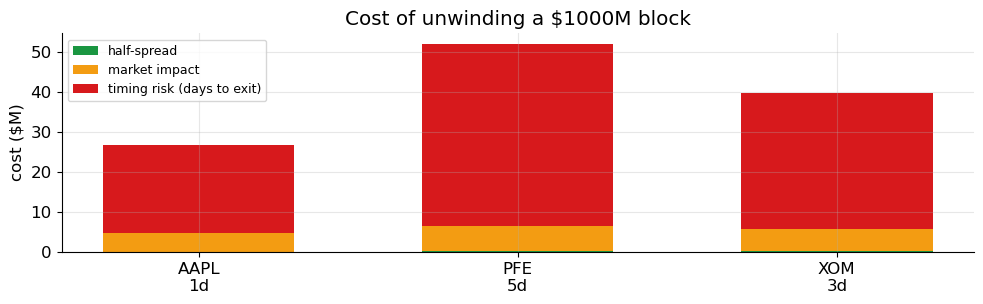

In [7]:
BLOCK, PARTIC_MAX, ETA = BOOK, 0.20, 1.0
z_liq = stats.norm.ppf(0.99)
adv_252 = (close * volume).tail(252).mean()

print(f'Unwinding the same ${BLOCK/1e6:.0f}M block in each name, never trading more than '
      f'{PARTIC_MAX:.0%} of a day\'s volume:\n')
hdr = (f"{'':>6}  {'ADV ($bn/day)':>13}  {'20% of ADV':>11}  {'days':>5}  {'half-spread':>12}  "
       f"{'impact':>10}  {'timing risk':>12}  {'total':>10}  {'% of block':>10}")
print(hdr); print('-'*len(hdr))
endo = {}
for s in STOCKS:
    sigma_d = ret[s].std()
    hs      = HALF_SPREAD[s]
    advd    = adv_252[s]
    T       = max(1.0, np.ceil(BLOCK / (PARTIC_MAX*advd)))
    x       = (BLOCK/advd) / T
    spread_cost = BLOCK * hs
    impact      = BLOCK * ETA * sigma_d * np.sqrt(x)
    timing      = z_liq * sigma_d * BLOCK * np.sqrt(T/3.0)
    tot         = spread_cost + impact + timing
    endo[s] = dict(T=T, spread=spread_cost, impact=impact, timing=timing, total=tot)
    print(f'{s:>6}  ${advd/1e9:>12.2f}  ${PARTIC_MAX*advd/1e6:>9.0f}M  {int(T):>5}  '
          f'${spread_cost/1e6:>11.2f}M  ${impact/1e6:>9.2f}M  ${timing/1e6:>11.2f}M  '
          f'${tot/1e6:>9.2f}M  {tot/BLOCK:>9.2%}')

print(f"\nPFE takes {int(endo['PFE']['T'])} days to exit vs {int(endo['AAPL']['T'])} for AAPL, and costs "
      f"{endo['PFE']['total']/endo['AAPL']['total']:.1f}x as much to get out of.")
print(f"The half-spread is {endo['PFE']['total']/endo['PFE']['spread']:.0f}x too small to describe "
      f"PFE's real exit cost.")

fig, ax = plt.subplots(figsize=(10, 3.2))
b = np.arange(len(STOCKS)); w = 0.6
sp = np.array([endo[s]['spread']/1e6 for s in STOCKS])
im = np.array([endo[s]['impact']/1e6 for s in STOCKS])
tm = np.array([endo[s]['timing']/1e6 for s in STOCKS])
ax.bar(b, sp, w, label='half-spread', color=GREEN)
ax.bar(b, im, w, bottom=sp, label='market impact', color=GOLD)
ax.bar(b, tm, w, bottom=sp+im, label='timing risk (days to exit)', color=RED)
ax.set_xticks(b); ax.set_xticklabels([f'{s}\n{int(endo[s]["T"])}d' for s in STOCKS])
ax.set_ylabel('cost ($M)'); ax.set_title(f'Cost of unwinding a ${BLOCK/1e6:.0f}M block')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation:** PFE is clearly the least liquid, with an Amihud ratio of 0.011 against AAPL's 0.0009 and about $1bn of daily volume against AAPL's $12bn. On a $1bn book my own Amihud measure charges 0.196%, lifting the VaR from 2.32% to 2.52%, while a quoted half-spread charges 0.017% and would have said 2.34%. I take the Amihud number as the answer because it is built from my own prices and volumes and, unlike a spread, it knows how much I am holding: the same names cost 0.002% to exit on a $10M book and 0.196% on $1bn. A rising line and a flat one must cross somewhere, and here it is near $100M, so a spread-based charge is right for exactly one book size and wrong either side of it. It prices the first share I sell and assumes the other billion dollars leave on the same terms.

Corwin-Schultz is the other reason to be suspicious, because it failed outright. It puts AAPL's spread at 43bp when the real quoted spread is under 1bp, and ranks XOM tighter than AAPL, which is simply wrong. Half the days give a negative alpha it floors at zero, and AAPL's median is 10bp against a mean of 43bp, so it is mostly noise: it reads the spread off the daily high-low range, and for tick-tight names that range is volatility and overnight gaps, not the bid-ask bounce it hunts.

Unwinding that same $1bn block one name at a time is worse again. AAPL is gone in a day but PFE takes 5, since 20% of PFE's daily volume is only about $243M, and the unsold rest stays exposed meanwhile. Timing risk is $45.7M and impact $6.2M against a $0.3M half-spread, so exiting PFE costs 5.22% of the block against AAPL's 2.68%, and the gap is days, not spread.

Two caveats I should be straight about. That timing term is market risk on the shrinking position, which is the same thing my base VaR already charges for over one day, so the block total is the cost of a slow exit rather than something to stack on top of the 2.52%. It is also the term that dominates, $45.7M of PFE's $52.2M, so most of what makes PFE expensive is holding it, not trading it. And my two measures disagree by construction: Amihud charges impact in proportion to size while the block model uses a square-root law, so they part company as the position grows. Amihud is what my data measures, the square-root law is the standard choice for an order fed in gradually, and I would not add them together. Both point the same way, which is the part that matters. Liquidity risk is being stuck holding something for five days while it falls, and those days arrive when everyone else is selling the same name.

## 5 · Operational-loss distribution

My parameters are judgemental. A large-cap non-financial faces a handful of material events a year across product liability, litigation, cyber and environmental, so I take 3 a year, a $5M median event, and sigma 1.5 for a tail reaching the billions these firms operate in.

Frequency: Poisson(lambda=3.0)  |  Severity: lognormal, median $5M, mean $15.4M
Expected annual op loss:  $46.1M
99% annual op loss:       $342M
99.9% annual op loss:     $876M   ->  Op capital (99.9% - EL): $830M

Shape of the annual loss distribution:
  skew 9.92  |  excess kurtosis 234.5  (Normal = 0 for both)
  99.9% / 99%   ratio: 2.56
  99.9% / mean  ratio: 19.0
  Normal approx 99.9%: $294M vs simulated $876M -> a Normal understates the 99.9% loss by 66%
  and understates capital (99.9% - EL) by 70%


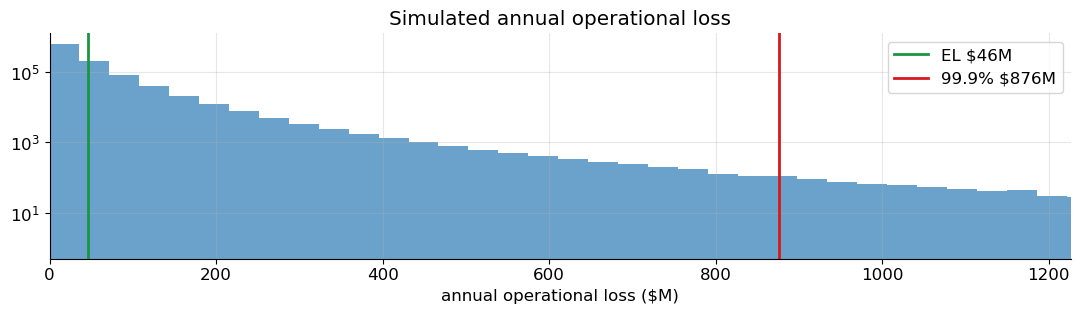

In [8]:
LAMBDA, MU_SEV, SIG_SEV = 3.0, np.log(5e6), 1.5
g = np.random.default_rng(123); YEARS = 1_000_000
counts = g.poisson(LAMBDA, YEARS)
sev    = g.lognormal(MU_SEV, SIG_SEV, counts.sum())
annual = np.bincount(np.repeat(np.arange(YEARS), counts), weights=sev, minlength=YEARS)

mean_sev = np.exp(MU_SEV + 0.5*SIG_SEV**2)
EL_OP  = annual.mean()
OP99   = np.percentile(annual, 99)
OP999  = np.percentile(annual, 99.9)
print(f'Frequency: Poisson(lambda={LAMBDA})  |  Severity: lognormal, median '
      f'${np.exp(MU_SEV)/1e6:.0f}M, mean ${mean_sev/1e6:.1f}M')
print(f'Expected annual op loss:  ${EL_OP/1e6:.1f}M')
print(f'99% annual op loss:       ${OP99/1e6:.0f}M')
print(f'99.9% annual op loss:     ${OP999/1e6:.0f}M   ->  Op capital (99.9% - EL): '
      f'${(OP999-EL_OP)/1e6:.0f}M')

normal_999 = annual.mean() + norm.ppf(0.999)*annual.std()
print(f'\nShape of the annual loss distribution:')
print(f'  skew {skew(annual):.2f}  |  excess kurtosis {kurtosis(annual):.1f}  '
      f'(Normal = 0 for both)')
print(f'  99.9% / 99%   ratio: {OP999/OP99:.2f}')
print(f'  99.9% / mean  ratio: {OP999/EL_OP:.1f}')
print(f'  Normal approx 99.9%: ${normal_999/1e6:.0f}M vs simulated ${OP999/1e6:.0f}M '
      f'-> a Normal understates the 99.9% loss by {100*(1-normal_999/OP999):.0f}%')
print(f'  and understates capital (99.9% - EL) by '
      f'{100*(1-(normal_999-EL_OP)/(OP999-EL_OP)):.0f}%')

fig, ax = plt.subplots(figsize=(11, 3.3))
ax.hist(annual/1e6, bins=120, color=BLUE, alpha=.7)
ax.axvline(EL_OP/1e6, color=GREEN, lw=2, label=f'EL ${EL_OP/1e6:.0f}M')
ax.axvline(OP999/1e6, color=RED, lw=2, label=f'99.9% ${OP999/1e6:.0f}M')
ax.set_xlim(0, OP999/1e6*1.4); ax.set_yscale('log')
ax.set_xlabel('annual operational loss ($M)')
ax.set_title('Simulated annual operational loss'); ax.legend()
plt.tight_layout(); plt.show()

In [9]:
def lda_capital(lam, mu, sg, years=YEARS, seed=123):
    gg = np.random.default_rng(seed)
    c  = gg.poisson(lam, years)
    sv = gg.lognormal(mu, sg, c.sum())
    a  = np.bincount(np.repeat(np.arange(years), c), weights=sv, minlength=years)
    return np.percentile(a, 99.9) - a.mean()

base = lda_capital(LAMBDA, MU_SEV, SIG_SEV)
print('Sensitivity of the 99.9% capital number to my assumptions:\n')
print(f"  {'assumption':<28}{'capital':>12}{'vs base':>10}")
print('  ' + '-'*48)
for lam in [1.5, 3.0, 6.0]:
    c = lda_capital(lam, MU_SEV, SIG_SEV)
    print(f"  {'lambda = ' + str(lam) + ' events/yr':<28}${c/1e6:>10.0f}M{c/base:>9.2f}x")
for sg in [1.0, 1.5, 2.0, 2.5]:
    c = lda_capital(LAMBDA, MU_SEV, sg)
    mean_sg = np.exp(MU_SEV + 0.5*sg**2)
    print(f"  {'severity sigma = ' + str(sg):<28}${c/1e6:>10.0f}M{c/base:>9.2f}x"
          f"   (mean event ${mean_sg/1e6:.1f}M)")

print('')
print('Raising sigma also raises the mean event, so the rows above mix a fatter tail')
print('with a bigger average loss. Holding the mean event fixed at $15.4M isolates')
print('the tail shape on its own:')
for sg in [1.0, 1.5, 2.0, 2.5]:
    mu_fixed = MU_SEV + 0.5*(SIG_SEV**2 - sg**2)
    c = lda_capital(LAMBDA, mu_fixed, sg)
    print(f"  {'sigma = ' + str(sg) + ' (mean held)':<28}${c/1e6:>10.0f}M{c/base:>9.2f}x"
          f"   (mean event ${np.exp(mu_fixed + 0.5*sg**2)/1e6:.1f}M)")

def business_indicator_component(BI):
    b1, b2 = 1e9, 30e9
    if BI <= b1: return 0.12*BI
    if BI <= b2: return 0.12*b1 + 0.15*(BI - b1)
    return 0.12*b1 + 0.15*(b2 - b1) + 0.18*(BI - b2)

def internal_loss_multiplier(LC, BIC):
    return np.log(np.e - 1 + (LC/BIC)**0.8)

BI  = 20e9
LC  = 15 * EL_OP
print('The SMA is a bank capital rule, so it does not apply to AAPL, PFE or XOM directly.')
print('I run it for a mid-size bank carrying a loss profile like theirs, as the')
print('standardized comparator to the internal model above.')
BIC = business_indicator_component(BI)
ILM = internal_loss_multiplier(LC, BIC)
print(f'\nBasel SMA (the rule since 2023), for a mid-size bank with BI = ${BI/1e9:.0f}bn:')
print(f'  BIC ${BIC/1e9:.2f}bn  x  ILM {ILM:.3f}  =  SMA capital ${BIC*ILM/1e9:.2f}bn')
print(f'  My 99.9% economic capital: ${(OP999-EL_OP)/1e9:.2f}bn  '
      f'-> SMA charges {BIC*ILM/(OP999-EL_OP):.1f}x my internal model')

Sensitivity of the 99.9% capital number to my assumptions:

  assumption                       capital   vs base
  ------------------------------------------------
  lambda = 1.5 events/yr      $       620M     0.75x
  lambda = 3.0 events/yr      $       830M     1.00x


  lambda = 6.0 events/yr      $      1092M     1.32x
  severity sigma = 1.0        $       161M     0.19x   (mean event $8.2M)
  severity sigma = 1.5        $       830M     1.00x   (mean event $15.4M)
  severity sigma = 2.0        $      4485M     5.40x   (mean event $36.9M)


  severity sigma = 2.5        $     24484M    29.50x   (mean event $113.8M)

Raising sigma also raises the mean event, so the rows above mix a fatter tail
with a bigger average loss. Holding the mean event fixed at $15.4M isolates
the tail shape on its own:
  sigma = 1.0 (mean held)     $       301M     0.36x   (mean event $15.4M)
  sigma = 1.5 (mean held)     $       830M     1.00x   (mean event $15.4M)
  sigma = 2.0 (mean held)     $      1870M     2.25x   (mean event $15.4M)


  sigma = 2.5 (mean held)     $      3314M     3.99x   (mean event $15.4M)
The SMA is a bank capital rule, so it does not apply to AAPL, PFE or XOM directly.
I run it for a mid-size bank carrying a loss profile like theirs, as the
standardized comparator to the internal model above.

Basel SMA (the rule since 2023), for a mid-size bank with BI = $20bn:
  BIC $2.97bn  x  ILM 0.708  =  SMA capital $2.10bn
  My 99.9% economic capital: $0.83bn  -> SMA charges 2.5x my internal model


**Interpretation:** The average year loses $46.1M but the 99.9% year loses $876M, so operational capital is about $830M. That factor of 19 between a typical year and the extreme is the signature of operational risk. The tail is wild, skew 9.9 and excess kurtosis 234 against 0 for a Normal, and a Normal on the same mean and standard deviation puts the 99.9% loss at $294M, understating it by 66% and the capital behind it by 70%. It is not abstract for these names: Pfizer paid $2.3bn in 2009 over off-label marketing of Bextra, the largest healthcare fraud settlement in US history at the time, and nearly three times my whole 99.9% year.

What I did not expect is how lopsided the sensitivity is. Doubling frequency from 3 events a year to 6 raises capital 32%, while moving severity sigma from 1.5 to 2.0 multiplies it 5.4x and 2.5 multiplies it 29.5x. But that flatters my own point, because raising sigma quietly raises the mean event too, from $15.4M to $36.9M, so those rows mix a fatter tail with a simply bigger loss. Holding the mean fixed at $15.4M isolates the tail, and capital still moves 2.25x at sigma 2.0 and 4.0x at 2.5, so tail shape does beat frequency, by three times rather than twenty. Poisson averaging works in my favour and the lognormal tail does not: more events makes the count more predictable, so it adds to the mean, whereas a longer tail stretches the single worst event, and at the 99.9% quantile the annual total is basically that one event. The parameter I have least evidence for still sets the answer, which is why Basel scrapped internal models here. The SMA is a bank rule, so it does not touch AAPL, PFE or XOM, but run for a mid-size bank carrying losses like theirs it charges $2.10bn against my $0.83bn. It gets there off a formula that reads my size and my average loss and never asks what my tail looks like. Cruder, but nobody can tune it down by arguing sigma is 1.5.

## 6 · Basel: credit, market & operational risk

The idea holding all of this together is the split between expected and unexpected loss. Expected loss is a cost of doing business, priced into the loan and provisioned for, so capital is not meant to cover it. Capital is for the unexpected part, the gap between an average year and a bad one, which is what every VaR here measures, and the confidence level is the regulator choosing how bad a year the bank must survive.

Each risk gets the same two-track treatment. Credit is either standardized risk weights off the borrower's rating, or the internal-ratings-based charge, which is the Vasicek formula my granular pool matched almost exactly. PD, LGD and correlation go in and capital comes out, but it only works by assuming a large diversified pool, so it charges for systematic risk and assumes the idiosyncratic part away. My three-name book is the case it cannot see, since nearly all my risk is one borrower failing alone, and it fixes correlation at one Gaussian constant when my atom table showed joint defaults are the only place correlation does anything.

Market risk has a sensitivities-based standardized charge built from prescribed delta, vega and curvature weights, and an internal models approach for desks that pass a P&L attribution test. Under FRTB that internal track measures Expected Shortfall rather than VaR, because a quantile says nothing about what sits behind it, which is the blindness I hit in section 2 where the 99% number sat frozen on one atom. Its liquidity horizons make my section 4 argument for me, and my PFE block needing five days is the case they had in mind. Operational risk went further, with Basel retiring internal models like mine for the standardized SMA. My own sensitivity table is the argument for that, since a parameter I cannot pin down moved capital several times over, and a model that steerable is worth less than a cruder rule nobody can argue with.

All four models tell me the same thing about themselves. Each ranked my firms sensibly and none could be trusted on the level. Merton got the ordering right and missed the PD by 13 sigma, the copula priced concentration and then froze at 99%, the half-spread ranked my names correctly and understated the cost of leaving PFE by 174x. Good at relative risk, poor at absolute numbers, so I check the level against something outside the model.